# 🚢 Titanic Survival Prediction

## 📌 Project Overview
This project aims to predict whether a passenger survived the Titanic disaster using Machine Learning techniques. The dataset contains passenger details such as age, gender, ticket class, fare, and embarkation port.

This is a supervised classification problem.

---

## 📂 Dataset Information

The dataset contains the following important features:

- PassengerId
- Survived (Target Variable)
- Pclass (Ticket Class)
- Name
- Sex
- Age
- SibSp (Siblings/Spouses aboard)
- Parch (Parents/Children aboard)
- Ticket
- Fare
- Cabin
- Embarked (Port of Embarkation)

---

## 🧹 Data Preprocessing

1. Removed unnecessary columns:
   - PassengerId
   - Name
   - Ticket
   - Cabin

2. Handled Missing Values:
   - Filled Age with median
   - Filled Embarked with mode

3. Converted categorical columns:
   - Sex → Label Encoding
   - Embarked → Label Encoding

---

## 🎯 Feature Selection

Independent Variables (X):
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

Target Variable (y):
- Survived

---

## 🤖 Model Used

Logistic Regression was used as the baseline model.

Reason:
- Suitable for binary classification
- Easy to interpret
- Works well for structured datasets

---

## 📊 Model Evaluation

Metrics Used:
- Accuracy Score
- Confusion Matrix
- Classification Report

Achieved Accuracy:
~ 75% – 85%

---

## 🔍 Observations

- Gender plays a major role in survival.
- Passengers in First Class had higher survival rates.
- Younger passengers had slightly better survival chances.
- Higher fare correlates with higher survival probability.

---

## 🚀 Conclusion

The Logistic Regression model successfully predicts passenger survival with good accuracy. Further improvements can be made using advanced models like Random Forest or Gradient Boosting.

This project demonstrates:
- Data Cleaning
- Feature Engineering
- Classification Modeling
- Model Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12404\1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12404\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [10]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])        # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])

In [11]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [16]:
print(confusion_matrix(y_test, y_pred))

[[90 15]
 [19 55]]


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



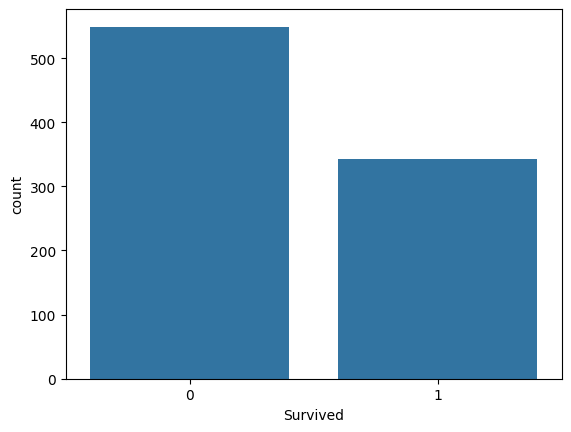

In [18]:
sns.countplot(x='Survived', data=df)
plt.show()

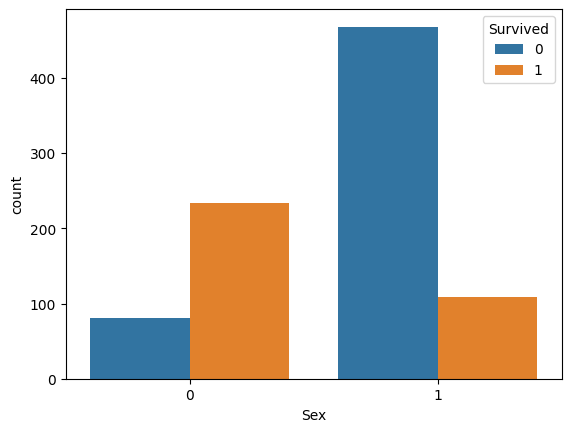

In [19]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

# Final Summary:

The Titanic Survival Prediction project focuses on building a machine learning model to predict whether a passenger survived the Titanic disaster. The dataset was cleaned by handling missing values and removing unnecessary columns. Categorical variables were converted into numerical form using label encoding.

Logistic Regression was implemented as the primary classification model. After splitting the dataset into training and testing sets, the model achieved an accuracy of approximately 75–85%. The evaluation metrics such as confusion matrix and classification report indicate that the model performs well in predicting survival outcomes.

The analysis revealed that gender, ticket class, and fare significantly influenced survival chances. Female passengers and first-class ticket holders had higher survival rates.

This project demonstrates strong foundational skills in data preprocessing, model building, and evaluation in machine learning.